In [2]:
# Install yfinance library for downloading stock market data
!pip install yfinance

In [3]:
# Import pandas for data handling
import pandas as pd

# Import numpy for numerical operations
import numpy as np

# Import yfinance to download stock data
import yfinance as yf

# Import train_test_split to divide dataset into training and testing sets
from sklearn.model_selection import train_test_split

# Import Linear Regression model
from sklearn.linear_model import LinearRegression

# Import Mean Absolute Error for model evaluation
from sklearn.metrics import mean_absolute_error

# Import matplotlib for plotting graphs
import matplotlib.pyplot as plt

In [4]:
# Download Apple stock data from Yahoo Finance
df = yf.download('AAPL', start='2020-01-01', end='2025-01-01')

# Display first 5 rows of dataset
print(df.head())

/tmp/ipykernel_9311/2813443750.py:2: FutureWarning: YF.download() has changed argument auto_adjust default to True
  df = yf.download('AAPL', start='2020-01-01', end='2025-01-01')
[*********************100%***********************]  1 of 1 completed

Price           Close       High        Low       Open     Volume
Ticker           AAPL       AAPL       AAPL       AAPL       AAPL
Date                                                             
2020-01-02  72.333893  72.394101  71.091199  71.344069  135480400
2020-01-03  71.630630  72.389250  71.406659  71.563198  146322800
2020-01-06  72.201431  72.239965  70.503569  70.754036  118387200
2020-01-07  71.861855  72.466338  71.642697  72.211056  108872000
2020-01-08  73.017830  73.318870  71.565614  71.565614  132079200


In [5]:
# Display shape of dataset (rows and columns)
print(df.shape)

# Display dataset column names
print(df.columns)

# Display dataset information
print(df.info())

(1258, 5)
MultiIndex([( 'Close', 'AAPL'),
            (  'High', 'AAPL'),
            (   'Low', 'AAPL'),
            (  'Open', 'AAPL'),
            ('Volume', 'AAPL')],
           names=['Price', 'Ticker'])
<class 'pandas.core.frame.DataFrame'>
DatetimeIndex: 1258 entries, 2020-01-02 to 2024-12-31
Data columns (total 5 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   (Close, AAPL)   1258 non-null   float64
 1   (High, AAPL)    1258 non-null   float64
 2   (Low, AAPL)     1258 non-null   float64
 3   (Open, AAPL)    1258 non-null   float64
 4   (Volume, AAPL)  1258 non-null   int64  
dtypes: float64(4), int64(1)
memory usage: 59.0 KB
None


In [6]:
# Select input features
X = df[['Open', 'High', 'Low', 'Volume']]

# Select target variable (Close price)
y = df['Close']

In [7]:
# Split dataset into training and testing data
X_train, X_test, y_train, y_test = train_test_split(
    X,                 # Input features
    y,                 # Target values
    test_size=0.2,     # 20% data for testing
    random_state=42    # Random state for reproducibility
)

In [8]:
# Create Linear Regression model
model = LinearRegression()

# Train model using training data
model.fit(X_train, y_train)

LinearRegression()

In [9]:
# Predict stock prices using testing data
predictions = model.predict(X_test)

# Display first 5 predicted values
print(predictions[:5])

[[169.21619962]
 [ 77.80382333]
 [ 59.74103848]
 [ 58.3209387 ]
 [167.88029373]]


In [10]:
# Calculate Mean Absolute Error
mae = mean_absolute_error(y_test, predictions)

# Print model error
print("Mean Absolute Error:", mae)

Mean Absolute Error: 0.7418783279361986


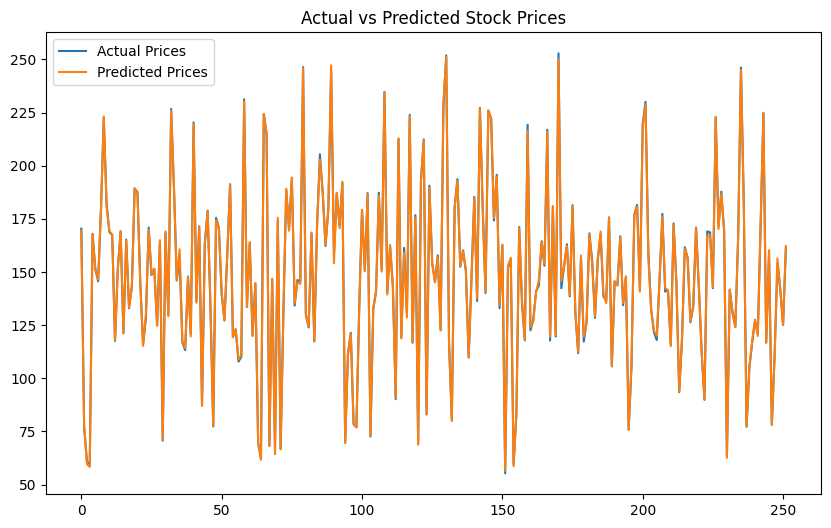

In [11]:
# Set graph size
plt.figure(figsize=(10,6))

# Plot actual stock prices
plt.plot(y_test.values, label='Actual Prices')

# Plot predicted stock prices
plt.plot(predictions, label='Predicted Prices')

# Add graph title
plt.title('Actual vs Predicted Stock Prices')

# Display legend
plt.legend()

# Show graph
plt.show()

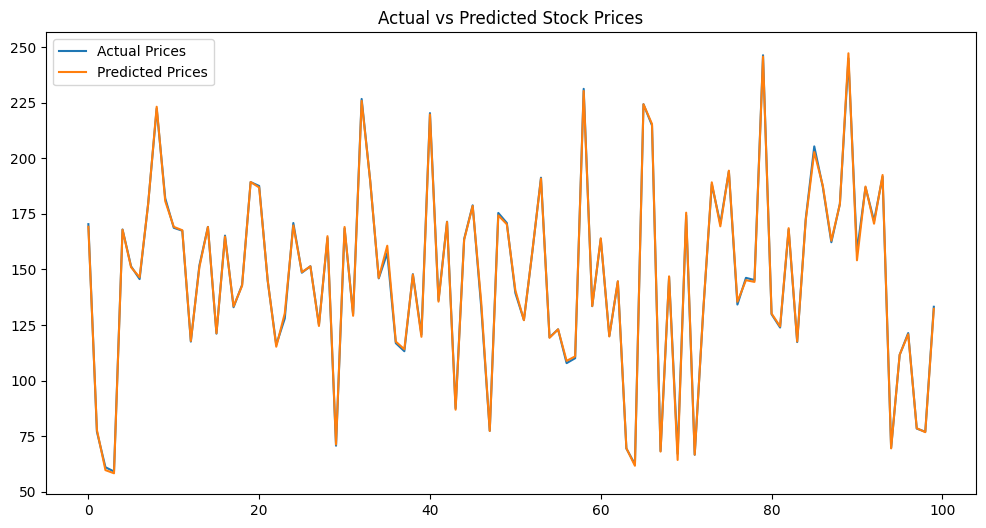

In [12]:
# Reset index for proper plotting
y_test = y_test.reset_index(drop=True)

# Create figure
plt.figure(figsize=(12,6))

# Plot actual prices
plt.plot(y_test[:100], label='Actual Prices')

# Plot predicted prices
plt.plot(predictions[:100], label='Predicted Prices')

# Add title
plt.title('Actual vs Predicted Stock Prices')

# Show legend
plt.legend()

# Display graph
plt.show()